## Neural Collaborative Filtering (NCF)

In [112]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

In [113]:
df = pd.read_csv('../../data/children_products/clildren_product_cleaned.csv')
print(f"Размер: {df.shape}")
df.head()

Размер: (610913, 16)


,Дата,НомерЗаказаНаСайте,МетодДоставки,Группа2,Группа3,Тип,Отменено,Количество,Цена,Статус,Гео,Маржа,СуммаУслуг,Телефон_new,ID_SKU,МетодДоставки_Групп
0,2017-03-01 11:41:00,3998972_TR,Курьерская,КРУПНОГАБАРИТНЫЙ ТОВАР,КОЛЯСКИ,КГТ,Нет,1,680.0,Возврат,Москва,508.00,0,55574854-48574951555577,ID9010020114553,Курьерская
1,2017-03-01 12:22:00,3999117_TR,Магазины,"ТЕКСТИЛЬ, ТРИКОТАЖ",ОДЕЖДА ДЛЯ НОВОРОЖДЕННЫХ (0-2 лет),ОДЕЖДА,Нет,1,379.0,Доставлен,Регионы,169.20,0,55575453-56535648535679,IDL00028974351,Магазины
2,2017-03-01 12:31:00,3999122_TR,Магазины,ИГРУШКИ,ИГРУШКИ ДЛЯ ДЕВОЧЕК,ИГРУШКИ,Нет,1,3325.0,Доставлен,Регионы,2176.00,0,55574950-57515657535772,IDL00038573351,Магазины
3,2017-03-01 03:06:00,3999363_TR,Курьерская,"ТЕКСТИЛЬ, ТРИКОТАЖ",ОДЕЖДА ДЛЯ НОВОРОЖДЕННЫХ (0-2 лет),ОДЕЖДА,Нет,1,330.0,Доставлен,Москва,163.04,0,55574851-55545249535475,IDL00034303856,Курьерская
4,2017-03-01 11:38:00,3999411_TR,Магазины,ИГРУШКИ,ИГРУШКИ ДЛЯ РАЗВИТИЯ МАЛЫШЕЙ,ИГРУШКИ,Нет,1,199.0,Доставлен,Регионы,120.00,0,55574854-56495552515179,IDL00035791553,Магазины


In [114]:
df.info()
print(df['Статус'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 610913 entries, 0 to 610912
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Дата                 610913 non-null  object 
 1   НомерЗаказаНаСайте   610913 non-null  object 
 2   МетодДоставки        610913 non-null  object 
 3   Группа2              610913 non-null  object 
 4   Группа3              610913 non-null  object 
 5   Тип                  610913 non-null  object 
 6   Отменено             610913 non-null  object 
 7   Количество           610913 non-null  int64  
 8   Цена                 610913 non-null  float64
 9   Статус               610913 non-null  object 
 10  Гео                  610913 non-null  object 
 11  Маржа                610913 non-null  float64
 12  СуммаУслуг           610913 non-null  int64  
 13  Телефон_new          610913 non-null  object 
 14  ID_SKU               610913 non-null  object 
 15  МетодДоставки_Гру

In [115]:
df_filtered = df[(df['Статус'] == 'Доставлен') & (df['Отменено'] == 'Нет')].copy()
print(f"После фильтрации: {df_filtered.shape}")

После фильтрации: (420857, 16)


In [116]:
df_filtered = df_filtered.dropna(subset=['Телефон_new', 'ID_SKU', 'Дата'])
df_filtered['Дата'] = pd.to_datetime(df_filtered['Дата'], errors='coerce')
df_filtered = df_filtered.dropna(subset=['Дата'])
print(f"Диапазон дат: {df_filtered['Дата'].min()} - {df_filtered['Дата'].max()}")

Диапазон дат: 2017-03-01 00:03:00 - 2017-04-30 23:58:00


In [117]:
# Фильтрация редких пользователей и товаров (минимум 3 покупки)
MIN_INTERACTIONS = 3

for iteration in range(5):  # итеративно, т.к. удаление пользователей может сделать товары редкими и наоборот
    user_counts = df_filtered.groupby('Телефон_new').size()
    item_counts = df_filtered.groupby('ID_SKU').size()
    active_users = user_counts[user_counts >= MIN_INTERACTIONS].index
    active_items = item_counts[item_counts >= MIN_INTERACTIONS].index
    before = len(df_filtered)
    df_filtered = df_filtered[
        df_filtered['Телефон_new'].isin(active_users) &
        df_filtered['ID_SKU'].isin(active_items)
    ]
    if len(df_filtered) == before:
        break

n_users = df_filtered['Телефон_new'].nunique()
n_items = df_filtered['ID_SKU'].nunique()
n_interactions = len(df_filtered)
density = n_interactions / (n_users * n_items) * 100
print(f"После фильтрации (≥{MIN_INTERACTIONS} покупок):")
print(f"  Пользователей: {n_users:,}, Товаров: {n_items:,}")
print(f"  Взаимодействий: {n_interactions:,}")
print(f"  Плотность матрицы: {density:.4f}%")

После фильтрации (≥3 покупок):
  Пользователей: 30,775, Товаров: 17,830
  Взаимодействий: 299,868
  Плотность матрицы: 0.0546%


In [118]:
interactions = df_filtered.groupby(['Телефон_new', 'ID_SKU']).size().reset_index(name='count')
print(f"Уникальных пар: {len(interactions):,}")
user_encoder = LabelEncoder()
item_encoder = LabelEncoder()
interactions['user_id'] = user_encoder.fit_transform(interactions['Телефон_new'])
interactions['item_id'] = item_encoder.fit_transform(interactions['ID_SKU'])
user_id_to_phone = dict(zip(interactions['user_id'], interactions['Телефон_new']))
item_id_to_sku = dict(zip(interactions['item_id'], interactions['ID_SKU']))

Уникальных пар: 272,920


In [119]:
interactions_with_date = df_filtered.merge(
    interactions[['Телефон_new', 'ID_SKU', 'user_id', 'item_id', 'count']],
    on=['Телефон_new', 'ID_SKU'], how='inner'
).sort_values('Дата')
split_date = interactions_with_date['Дата'].quantile(0.8)
print(f"Дата разделения: {split_date}")
train_data = interactions_with_date[interactions_with_date['Дата'] < split_date].copy()
test_data = interactions_with_date[interactions_with_date['Дата'] >= split_date].copy()
print(f"Train: {len(train_data):,}, Test: {len(test_data):,}")

Дата разделения: 2017-04-18 14:18:00
Train: 239,880, Test: 59,988


In [120]:
train_interactions = train_data.groupby(['user_id', 'item_id'])['count'].sum().reset_index()
test_interactions = test_data.groupby(['user_id', 'item_id'])['count'].sum().reset_index()
train_users = set(train_interactions['user_id'].unique())
test_users = set(test_interactions['user_id'].unique())
print(f"Train users: {len(train_users):,}, Test users: {len(test_users):,}")

Train users: 26,838, Test users: 9,660


### Генерация негативных примеров: гибридный подход

Вместо чисто случайного сэмплинга используем **два типа негативов**:

1. **Hard negatives** — реальные отмены (`Отменен`) и возвраты (`Возврат`) из данных. Пользователь знал об этих товарах, но в итоге отказался → сильный негативный сигнал.
2. **Easy negatives** — случайные товары, с которыми пользователь не взаимодействовал. Дополняют до нужного соотношения 1:4.

Зачем: чисто случайные негативы — слишком простая задача (отличить купленный товар от случайного из другой категории). Hard negatives заставляют модель учить тонкие различия — почему пользователь купил товар A, но вернул похожий товар B.

In [121]:
# Hard negatives: отмены и возвраты
df_hard_neg = df[(df['Статус'].isin(['Отменен', 'Возврат'])) | (df['Отменено'] == 'Да')].copy()
df_hard_neg['Дата'] = pd.to_datetime(df_hard_neg['Дата'], errors='coerce')
df_hard_neg = df_hard_neg.dropna(subset=['Телефон_new', 'ID_SKU', 'Дата'])

known_phones = set(interactions['Телефон_new'])
known_skus = set(interactions['ID_SKU'])
df_hard_neg = df_hard_neg[
    df_hard_neg['Телефон_new'].isin(known_phones) &
    df_hard_neg['ID_SKU'].isin(known_skus)
]

phone_to_uid = dict(zip(interactions['Телефон_new'], interactions['user_id']))
sku_to_iid = dict(zip(interactions['ID_SKU'], interactions['item_id']))
df_hard_neg['user_id'] = df_hard_neg['Телефон_new'].map(phone_to_uid)
df_hard_neg['item_id'] = df_hard_neg['ID_SKU'].map(sku_to_iid)

positive_pairs = set(zip(train_interactions['user_id'], train_interactions['item_id']))
hard_neg_pairs = df_hard_neg[['user_id', 'item_id']].drop_duplicates()
hard_neg_pairs = hard_neg_pairs[
    ~hard_neg_pairs.apply(lambda r: (r['user_id'], r['item_id']) in positive_pairs, axis=1)
]
hard_neg_pairs['label'] = 0

print(f"Hard negatives (отмены + возвраты): {len(hard_neg_pairs):,}")

# Easy negatives: случайный сэмплинг, дополняем до соотношения 1:4
num_positives = len(train_interactions)
target_negatives = num_positives * 4
num_easy_needed = max(0, target_negatives - len(hard_neg_pairs))

def generate_negative_samples(interactions_df, n_items, num_negatives=4):
    user_items = interactions_df.groupby('user_id')['item_id'].apply(set).to_dict()
    negative_samples = []
    for _, row in interactions_df.iterrows():
        user_id = row['user_id']
        negatives_count = 0
        attempts = 0
        while negatives_count < num_negatives and attempts < num_negatives * 10:
            neg_item = np.random.randint(0, n_items)
            attempts += 1
            if neg_item not in user_items.get(user_id, set()):
                negative_samples.append({'user_id': user_id, 'item_id': neg_item, 'label': 0})
                negatives_count += 1
    return pd.DataFrame(negative_samples)

n_items_total = len(item_encoder.classes_)
easy_per_positive = max(1, int(np.ceil(num_easy_needed / num_positives)))
train_easy_negatives = generate_negative_samples(train_interactions, n_items_total, num_negatives=easy_per_positive)
if len(train_easy_negatives) > num_easy_needed:
    train_easy_negatives = train_easy_negatives.sample(n=num_easy_needed, random_state=42)

train_positives = train_interactions[['user_id', 'item_id']].copy()
train_positives['label'] = 1
train_samples = pd.concat([train_positives, hard_neg_pairs, train_easy_negatives], ignore_index=True)
train_samples = train_samples.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Позитивных: {len(train_positives):,}")
print(f"Hard negatives: {len(hard_neg_pairs):,}")
print(f"Easy negatives: {len(train_easy_negatives):,}")
print(f"Всего: {len(train_samples):,}")

Hard negatives (отмены + возвраты): 31,299
Позитивных: 220,920
Hard negatives: 31,299
Easy negatives: 852,381
Всего: 1,104,600


In [122]:
class NCFDataset(Dataset):
    def __init__(self, user_ids, item_ids, labels):
        self.user_ids = torch.LongTensor(user_ids)
        self.item_ids = torch.LongTensor(item_ids)
        self.labels = torch.FloatTensor(labels)
    def __len__(self): 
        return len(self.user_ids)
    def __getitem__(self, idx): 
        return self.user_ids[idx], self.item_ids[idx], self.labels[idx]

train_dataset = NCFDataset(train_samples['user_id'].values, train_samples['item_id'].values, train_samples['label'].values)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
print(f"Dataset: {len(train_dataset):,}, Батчей: {len(train_loader):,}")

Dataset: 1,104,600, Батчей: 4,315


In [123]:
class NCF(nn.Module):
    def __init__(self, num_users, num_items, emb_dim=32, hidden_dim=32, dropout=0.3):
        super().__init__()
        # GMF-ветка: отдельные эмбеддинги для матричной факторизации
        self.user_embedding_gmf = nn.Embedding(num_users, emb_dim)
        self.item_embedding_gmf = nn.Embedding(num_items, emb_dim)

        # MLP-ветка: отдельные эмбеддинги для глубокой сети
        self.user_embedding_mlp = nn.Embedding(num_users, emb_dim)
        self.item_embedding_mlp = nn.Embedding(num_items, emb_dim)

        self.mlp = nn.Sequential(
            nn.Linear(emb_dim * 2, hidden_dim * 2),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
        )

        # финальный слой: объединение GMF (emb_dim) + MLP (hidden_dim // 2)
        self.fc_out = nn.Linear(emb_dim + hidden_dim // 2, 1)

        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.user_embedding_gmf.weight, std=0.01)
        nn.init.normal_(self.item_embedding_gmf.weight, std=0.01)
        nn.init.normal_(self.user_embedding_mlp.weight, std=0.01)
        nn.init.normal_(self.item_embedding_mlp.weight, std=0.01)
        for m in self.mlp:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.constant_(m.bias, 0)
        nn.init.xavier_uniform_(self.fc_out.weight)
        nn.init.constant_(self.fc_out.bias, 0)

    def forward(self, user_ids, item_ids):
        # GMF: поэлементное произведение
        u_gmf = self.user_embedding_gmf(user_ids)
        v_gmf = self.item_embedding_gmf(item_ids)
        gmf_out = u_gmf * v_gmf

        # MLP: конкатенация через глубокую сеть
        u_mlp = self.user_embedding_mlp(user_ids)
        v_mlp = self.item_embedding_mlp(item_ids)
        mlp_out = self.mlp(torch.cat([u_mlp, v_mlp], dim=-1))

        # NeuMF: объединение двух веток
        x = torch.cat([gmf_out, mlp_out], dim=-1)
        logits = self.fc_out(x).squeeze(-1)
        y_hat = torch.sigmoid(logits)
        return y_hat

num_users = len(user_encoder.classes_)
num_items = len(item_encoder.classes_)

model = NCF(num_users, num_items, emb_dim=32, hidden_dim=32, dropout=0.3)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"Device: {device}, Params: {sum(p.numel() for p in model.parameters()):,}")

Device: cpu, Params: 3,117,761


In [124]:
from tqdm.notebook import tqdm

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-5)

num_epochs = 5
train_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", unit="batch")

    for user_ids, item_ids, labels in loop:
        user_ids = user_ids.to(device)
        item_ids = item_ids.to(device)
        labels = labels.to(device)

        predictions = model(user_ids, item_ids)
        loss = criterion(predictions, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}: avg_loss={avg_loss:.4f}")

Epoch 1/5:   0%|          | 0/4315 [00:00<?, ?batch/s]

Epoch 1: avg_loss=0.4084


Epoch 2/5:   0%|          | 0/4315 [00:00<?, ?batch/s]

Epoch 2: avg_loss=0.3647


Epoch 3/5:   0%|          | 0/4315 [00:00<?, ?batch/s]

Epoch 3: avg_loss=0.3429


Epoch 4/5:   0%|          | 0/4315 [00:00<?, ?batch/s]

Epoch 4: avg_loss=0.3244


Epoch 5/5:   0%|          | 0/4315 [00:00<?, ?batch/s]

Epoch 5: avg_loss=0.3073


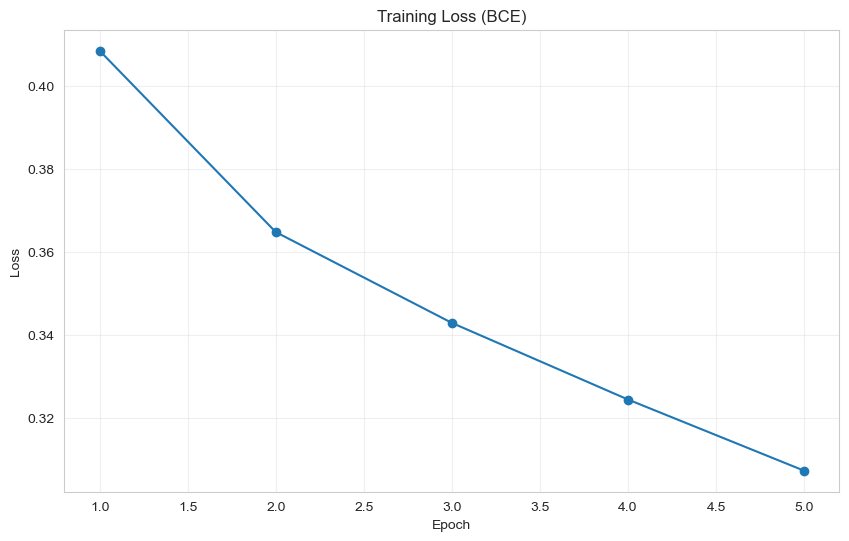

In [125]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss (BCE)')
plt.grid(True, alpha=0.3)
plt.show()

In [126]:
def get_recommendations_ncf(model, user_id, train_interactions, n_items, k=10, device="cpu"):
    model.eval()

    # товары пользователя в train
    user_history = train_interactions.loc[train_interactions["user_id"] == user_id, "item_id"]
    bought_items = set(user_history.to_numpy())  # тут ок, это pandas → numpy, не torch

    # все товары
    items = torch.arange(n_items, device=device, dtype=torch.long)
    users = torch.full_like(items, fill_value=user_id)

    with torch.no_grad():
        scores = model(users, items)
        scores = scores.detach().cpu()

    # фильтруем уже купленное
    candidates_idx = []
    candidates_scores = []
    for i in range(n_items):
        if i not in bought_items:
            candidates_idx.append(i)
            candidates_scores.append(scores[i].item())

    # находим top-k по torch, без numpy
    if len(candidates_idx) == 0:
        return [], []

    scores_tensor = torch.tensor(candidates_scores)
    topk_scores, topk_pos = torch.topk(scores_tensor, k=min(k, len(candidates_idx)))

    item_ids = [candidates_idx[pos] for pos in topk_pos.tolist()]
    item_scores = topk_scores.tolist()
    return item_ids, item_scores


In [127]:
def precision_at_k(recommended, relevant, k):
    if k == 0:
        return 0.0
    rec_k = set(recommended[:k])
    rel = set(relevant)
    if not rec_k:
        return 0.0
    return len(rec_k & rel) / len(rec_k)


def recall_at_k(recommended, relevant, k):
    rel = set(relevant)
    if not rel:
        return 0.0
    rec_k = set(recommended[:k])
    return len(rec_k & rel) / len(rel)


def map_at_k(recommended, relevant, k):
    rel = set(relevant)
    if not rel:
        return 0.0
    score = 0.0
    hits = 0.0
    for i, item in enumerate(recommended[:k]):
        if item in rel:
            hits += 1.0
            score += hits / (i + 1.0)
    return score / min(len(rel), k)


def ndcg_at_k(recommended, relevant, k):
    rel = set(relevant)
    if not rel:
        return 0.0
    dcg = 0.0
    for i, item in enumerate(recommended[:k]):
        if item in rel:
            dcg += 1.0 / np.log2(i + 2)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(rel), k)))
    return dcg / idcg if idcg > 0 else 0.0


In [128]:
def evaluate_model(model, train_interactions, test_interactions, n_items,
                   k_values=(5, 10, 20), device="cpu"):
    test_user_items = (
        test_interactions.groupby("user_id")["item_id"]
        .apply(list)
        .to_dict()
    )

    train_users = set(train_interactions["user_id"].unique())
    eval_users = [u for u in test_user_items.keys() if u in train_users]

    metrics = {
        k: {"precision": [], "recall": [], "map": [], "ndcg": []}
        for k in k_values
    }

    for user_id in eval_users:
        rec_items, _ = get_recommendations_ncf(
            model, user_id, train_interactions, n_items,
            k=max(k_values), device=device
        )
        relevant_items = test_user_items[user_id]

        for k in k_values:
            p = precision_at_k(rec_items, relevant_items, k)
            r = recall_at_k(rec_items, relevant_items, k)
            m = map_at_k(rec_items, relevant_items, k)
            n = ndcg_at_k(rec_items, relevant_items, k)

            metrics[k]["precision"].append(p)
            metrics[k]["recall"].append(r)
            metrics[k]["map"].append(m)
            metrics[k]["ndcg"].append(n)

    avg_metrics = {
        k: {
            "precision": float(np.mean(v["precision"])) if v["precision"] else 0.0,
            "recall":    float(np.mean(v["recall"]))    if v["recall"] else 0.0,
            "map":       float(np.mean(v["map"]))       if v["map"] else 0.0,
            "ndcg":      float(np.mean(v["ndcg"]))      if v["ndcg"] else 0.0,
        }
        for k, v in metrics.items()
    }
    return avg_metrics


In [129]:
results = evaluate_model(
    model,
    train_interactions,
    test_interactions,
    n_items=num_items,
    k_values=[5, 10, 20],
    device=device
)

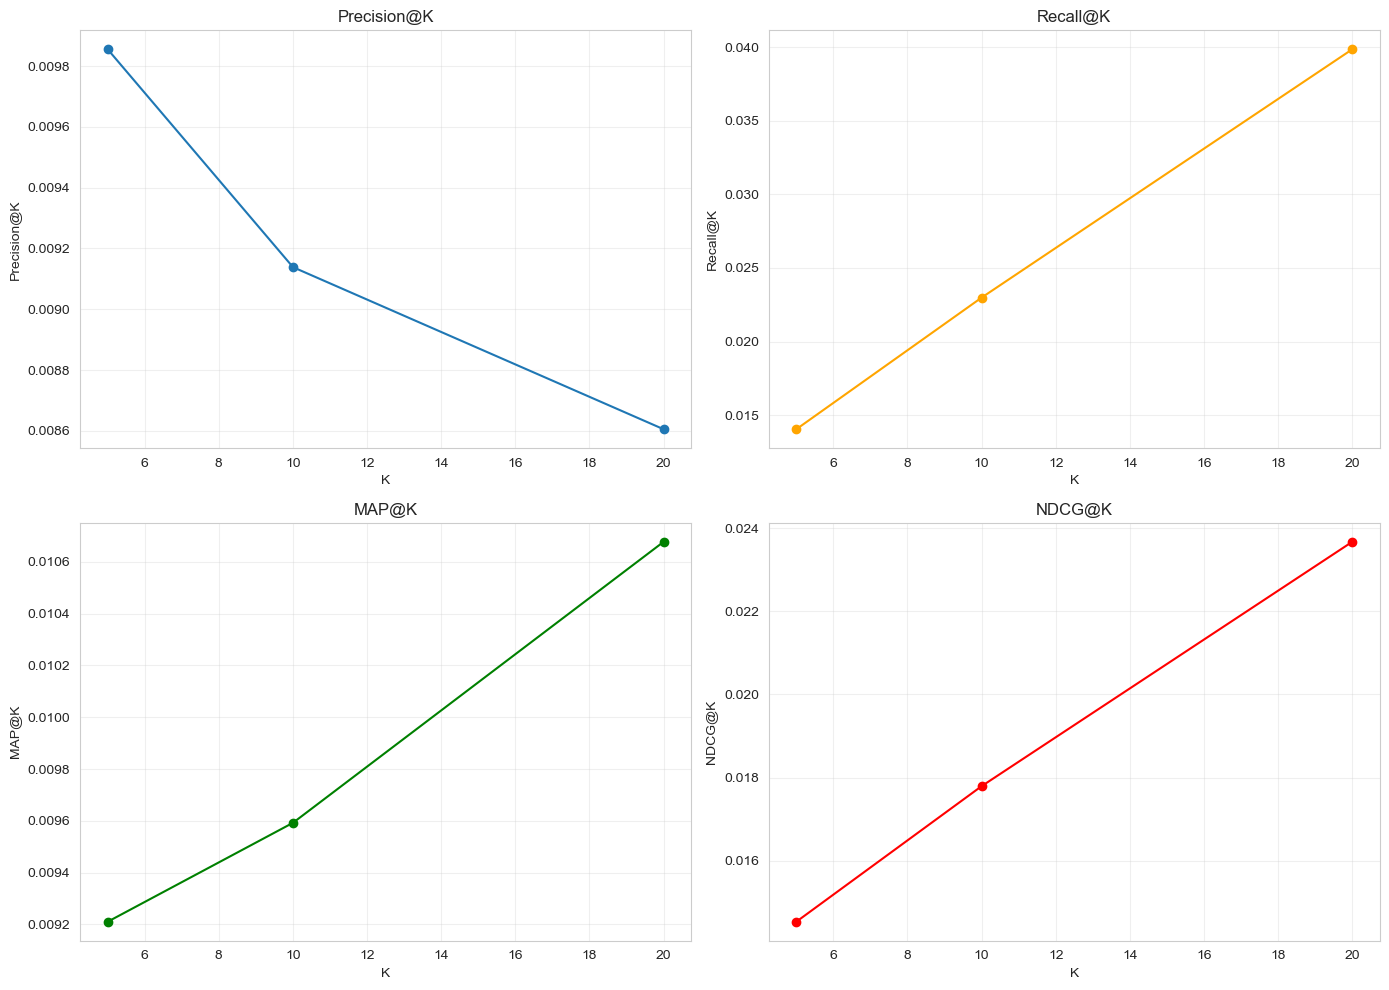

In [130]:
metrics_df = pd.DataFrame(results).T
metrics_df.index.name = "K"

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(metrics_df.index, metrics_df["precision"], marker="o")
axes[0, 0].set_xlabel("K"); axes[0, 0].set_ylabel("Precision@K")
axes[0, 0].set_title("Precision@K"); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(metrics_df.index, metrics_df["recall"], marker="o", color="orange")
axes[0, 1].set_xlabel("K"); axes[0, 1].set_ylabel("Recall@K")
axes[0, 1].set_title("Recall@K"); axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(metrics_df.index, metrics_df["map"], marker="o", color="green")
axes[1, 0].set_xlabel("K"); axes[1, 0].set_ylabel("MAP@K")
axes[1, 0].set_title("MAP@K"); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(metrics_df.index, metrics_df["ndcg"], marker="o", color="red")
axes[1, 1].set_xlabel("K"); axes[1, 1].set_ylabel("NDCG@K")
axes[1, 1].set_title("NDCG@K"); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [131]:

# Выведем текущие метрики
print("=== NCF (BPR) Metrics ===")
for k in [5, 10, 20]:
    r = results[k]
    print(f"\nK={k}:")
    print(f"  Precision@{k}: {r['precision']:.4f}")
    print(f"  Recall@{k}:    {r['recall']:.4f}")
    print(f"  MAP@{k}:       {r['map']:.4f}")
    print(f"  NDCG@{k}:      {r['ndcg']:.4f}")


=== NCF (BPR) Metrics ===

K=5:
  Precision@5: 0.0099
  Recall@5:    0.0141
  MAP@5:       0.0092
  NDCG@5:      0.0145

K=10:
  Precision@10: 0.0091
  Recall@10:    0.0230
  MAP@10:       0.0096
  NDCG@10:      0.0178

K=20:
  Precision@20: 0.0086
  Recall@20:    0.0398
  MAP@20:       0.0107
  NDCG@20:      0.0237
